<a href="https://colab.research.google.com/github/luiska147/telecom_x_1/blob/main/Desafio_Telecom_X_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data extraction

In [196]:
import requests
import pandas as pd

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
datos = pd.DataFrame(data)
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [197]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [198]:
datos_normalizados = pd.json_normalize(data)

datos_normalizados

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


## Transform Data

In [199]:
datos_normalizados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

### Verify each column

In [200]:
for col in datos_normalizados.columns:
  print(f'Valores unicos en la columna {col}: {datos_normalizados[col].nunique()}')

  if datos_normalizados[col].nunique() < 50:
    print(datos_normalizados[col].unique())
    print('-' * 50)


Valores unicos en la columna customerID: 7267
Valores unicos en la columna Churn: 3
['No' 'Yes' '']
--------------------------------------------------
Valores unicos en la columna customer.gender: 2
['Female' 'Male']
--------------------------------------------------
Valores unicos en la columna customer.SeniorCitizen: 2
[0 1]
--------------------------------------------------
Valores unicos en la columna customer.Partner: 2
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna customer.Dependents: 2
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna customer.tenure: 73
Valores unicos en la columna phone.PhoneService: 2
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna phone.MultipleLines: 3
['No' 'Yes' 'No phone service']
--------------------------------------------------
Valores unicos en la columna internet.InternetService: 3
['DSL' 'Fiber optic' 'No']
--------

### Verify duplicated data

In [201]:
print('Numero de duplicados', datos_normalizados.duplicated().sum())

Numero de duplicados 0


### Verify null data

In [202]:
print('Numero de nulos ', datos_normalizados.isnull().sum())

Numero de nulos  customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


### Verify empty data

In [203]:
datos_normalizados.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


### Transform and fix data

In [204]:
datos_normalizados['account.Charges.Total'] = datos_normalizados['account.Charges.Total'].apply(pd.to_numeric, errors='coerce')
print(datos_normalizados['account.Charges.Total'].dtype)

float64


In [205]:
datos_normalizados = datos_normalizados[datos_normalizados['Churn'].str.strip() != '']
print('Número de filas despues de eliminar vacios en columna "Churn"', len(datos_normalizados))

Número de filas despues de eliminar vacios en columna "Churn" 7043


In [206]:
datos_normalizados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

In [207]:
datos_normalizados = datos_normalizados.dropna(subset = ['account.Charges.Total'])
print('Numero de nulos\n', datos_normalizados.isnull().sum())

Numero de nulos
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [208]:
datos_normalizados['Cuentas diarias'] = datos_normalizados['account.Charges.Monthly']/30
datos_normalizados


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [209]:
datos_normalizados = datos_normalizados.rename(columns={
    'customerID': 'Id Cliente',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto Mayor',
    'customer.Partner': 'Tiene Pareja',
    'customer.Dependents': 'Tiene Dependientes',
    'customer.tenure': 'Meses de contrato',
    'phone.PhoneService': 'Tiene Servicio Telefonico',
    'phone.MultipleLines': 'Tiene Multiples Lineas',
    'internet.InternetService': 'Tiene Servicio de Internet',
    'internet.OnlineSecurity': 'Contrato OnlineSecurity',
    'internet.OnlineBackup': 'Contrato OnlineBackup',
    'internet.DeviceProtection': 'Contrato DeviceProtecion',
    'internet.TechSupport': 'Contrato TechSupport',
    'internet.StreamingTV': 'Contrato StreamingTV',
    'internet.StreamingMovies': 'Contrato StreamingMovies',
    'account.Contract': 'Tipo de contrato',
    'account.PaperlessBilling': 'Tiene Facturación Electronica',
    'account.PaymentMethod': 'Metodo de Pago',
    'account.Charges.Monthly': 'Cargos Mensuales',
    'account.Charges.Total': 'Cargos Totales'
})
datos_normalizados

,Id Cliente,Churn,Genero,Adulto Mayor,Tiene Pareja,Tiene Dependientes,Meses de contrato,Tiene Servicio Telefonico,Tiene Multiples Lineas,Tiene Servicio de Internet,Contrato OnlineSecurity,Contrato OnlineBackup,Contrato DeviceProtecion,Contrato TechSupport,Contrato StreamingTV,Contrato StreamingMovies,Tipo de contrato,Tiene Facturación Electronica,Metodo de Pago,Cargos Mensuales,Cargos Totales,Cuentas diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [210]:
mapeo_binario = {
    'Yes': 'Si',
    'No': 'No',
    'No internet service': 'Sin servicio de internet',
    'No phone service': 'Sin servicio de telefono',
    'Female': 'Femenino',
    'Male':'Masculino',
    'Mailed check': 'Cheque enviado por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de Crédito (automático)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)',
    'One year': 'Un año',
    'Month-to-month': 'Mes-a-mes',
    'Two year': 'Dos años',
    'Fiber optic': 'Fibra optica'

}
columnas_binarias = [
    'Churn',
    'Genero',
    'Tiene Pareja',
    'Tiene Dependientes',
    'Tiene Servicio Telefonico',
    'Tiene Multiples Lineas',
    'Tiene Servicio de Internet',
    'Contrato OnlineSecurity',
    'Contrato OnlineBackup',
    'Contrato DeviceProtecion',
    'Contrato TechSupport',
    'Contrato StreamingTV',
    'Contrato StreamingMovies',
    'Tipo de contrato',
    'Tiene Facturación Electronica',
    'Metodo de Pago'
]
datos_normalizados[columnas_binarias] = datos_normalizados[columnas_binarias].replace(mapeo_binario)
datos_normalizados

,Id Cliente,Churn,Genero,Adulto Mayor,Tiene Pareja,Tiene Dependientes,Meses de contrato,Tiene Servicio Telefonico,Tiene Multiples Lineas,Tiene Servicio de Internet,Contrato OnlineSecurity,Contrato OnlineBackup,Contrato DeviceProtecion,Contrato TechSupport,Contrato StreamingTV,Contrato StreamingMovies,Tipo de contrato,Tiene Facturación Electronica,Metodo de Pago,Cargos Mensuales,Cargos Totales,Cuentas diarias
0,0002-ORFBO,No,Femenino,0,Si,Si,9,Si,No,DSL,No,Si,No,Si,Si,No,Un año,Si,Cheque enviado por correo,65.60,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Si,Si,DSL,No,No,No,No,No,Si,Mes-a-mes,No,Cheque enviado por correo,59.90,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,0,No,No,4,Si,No,Fibra optica,No,No,Si,No,No,No,Mes-a-mes,Si,Cheque electrónico,73.90,280.85,2.463333
3,0011-IGKFF,Si,Masculino,1,Si,No,13,Si,No,Fibra optica,No,Si,Si,No,Si,Si,Mes-a-mes,Si,Cheque electrónico,98.00,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,1,Si,No,3,Si,No,Fibra optica,No,No,No,Si,Si,No,Mes-a-mes,Si,Cheque enviado por correo,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Femenino,0,No,No,13,Si,No,DSL,Si,No,No,Si,No,No,Un año,No,Cheque enviado por correo,55.15,742.90,1.838333
7263,9992-RRAMN,Si,Masculino,0,Si,No,22,Si,Si,Fibra optica,No,No,No,No,No,Si,Mes-a-mes,Si,Cheque electrónico,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Masculino,0,No,No,2,Si,No,DSL,No,Si,No,No,No,No,Mes-a-mes,Si,Cheque enviado por correo,50.30,92.75,1.676667
7265,9993-LHIEB,No,Masculino,0,Si,Si,67,Si,No,DSL,Si,No,Si,Si,No,Si,Dos años,No,Cheque enviado por correo,67.85,4627.65,2.261667


## Load & data analysis

In [211]:
datos_normalizados.describe()

,Adulto Mayor,Meses de contrato,Cargos Mensuales,Cargos Totales,Cuentas diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


In [212]:
import plotly.express as px


In [213]:
columnas_categoricas = [
    'Genero',
    'Adulto Mayor',
    'Tiene Pareja',
    'Tiene Dependientes',
    'Tiene Servicio Telefonico',
    'Tiene Facturación Electronica',
    'Tipo de contrato'
]

for col in columnas_categoricas:
    fig = px.histogram(
        datos_normalizados,
        x=col,
        color='Churn',
        barmode='group',
        text_auto=True,
        title=f'Distribución de Churn por {col}'
    )
    fig.update_layout(title_x=0.5, width=1000)
    fig.show()

In [214]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=3,
    subplot_titles=("Cargos Mensuales vs Churn", "Cargos Totales vs Churn", "Meses de Contrato vs Churn")
)

fig.add_trace(
    go.Box(x=datos_normalizados['Churn'], y=datos_normalizados['Cargos Mensuales'], name="Mensual", marker_color='indianred'),
    row=1, col=1
)

fig.add_trace(
    go.Box(x=datos_normalizados['Churn'], y=datos_normalizados['Cargos Totales'], name="Total", marker_color='lightseagreen'),
    row=1, col=2
)

fig.add_trace(
    go.Box(x=datos_normalizados['Churn'], y=datos_normalizados['Meses de contrato'], name="Meses", marker_color='royalblue'),
    row=1, col=3
)

fig.update_layout(
    title_text="Análisis de Variables Numéricas por Churn",
    title_x=0.5,
    showlegend=False,
    height=500
)
fig.show()

In [215]:
fig1 = px.histogram(
    datos_normalizados,
    x='Tiene Servicio Telefonico',
    color='Churn',
    facet_col='Tiene Servicio de Internet',
    barmode='group',
    title='Distribución de Churn por Servicio Telefónico e Internet'
)
fig1.update_layout(title_x=0.5, width=1000, height=450)
fig1.show()


fig2 = px.histogram(
    datos_normalizados,
    x='Meses de contrato',
    color='Churn',
    facet_col='Tiene Servicio de Internet',
    barmode='group',
    title='Distribución de Churn por Tiempo de Contrato e Internet'
)
fig2.update_layout(title_x=0.5, width=1200, height=450)
fig2.show()


fig3 = px.box(
    datos_normalizados,
    x='Metodo de Pago',
    y='Meses de contrato',
    color='Churn',
    title='Meses de Contrato vs Método de Pago (Separado por Churn)'
)
fig3.update_layout(title_x=0.5, width=1000, height=500)
fig3.show()


fig4 = px.box(
    datos_normalizados,
    x='Tipo de contrato',
    y='Meses de contrato',
    color='Churn',
    title='Permanencia (Meses de Contrato) según Tipo de Contrato y Churn'
)
fig4.update_layout(title_x=0.5, width=1000, height=500)
fig4.show()


fig5 = px.box(
    datos_normalizados,
    x='Metodo de Pago',
    y='Cargos Mensuales',
    color='Churn',
    title='Cargos Mensuales según Método de Pago y Churn'
)
fig5.update_layout(title_x=0.5, width=1000, height=500)
fig5.show()



# Informe Final: Análisis de Retención y Fuga de Clientes (Churn) - Telecom X

## 1. Objetivo del Proyecto
El presente informe tiene como propósito principal identificar, analizar y comprender las variables que influyen en la decisión de los clientes de cancelar sus servicios (Churn) con la empresa de telecomunicaciones Telecom X. A través de un análisis exploratorio de datos detallado, se busca descubrir patrones de comportamiento que permitan a la compañía tomar decisiones estratégicas fundamentadas para mejorar sus índices de retención.

## 2. Metodología y Preparación de Datos
Para garantizar la integridad y veracidad del análisis, se llevó a cabo un riguroso proceso de preprocesamiento estructurado en las siguientes fases:

* **Extracción y Normalización:** Se importó la información desde una API en formato JSON utilizando la biblioteca **Pandas**. Dado que los datos presentaban una estructura anidada (diccionarios dentro de columnas), se aplicaron técnicas de normalización para aplanar la información hacia un formato tabular clásico.
* **Auditoría y Limpieza:** Se verificó la consistencia de cada columna, confirmando la ausencia de registros duplicados. Se detectaron valores nulos o vacíos, específicamente en las columnas `Churn` y `Cargos Totales`. Se tomó la decisión analítica de eliminar estos registros atípicos, ya que imputar esta información (con medidas como la media o mediana) podría alterar o sesgar el comportamiento real de la muestra.
* **Transformación e Ingeniería de Características:** Se ajustaron los tipos de datos correspondientes a cada variable para permitir operaciones matemáticas. Se creó una nueva característica llamada `Cuentas diarias` (derivada del gasto mensual) para explorar nuevas dimensiones predictivas. Finalmente, se estandarizó la nomenclatura de las columnas y se transformaron variables de texto binarias a valores booleanos (Si y No), optimizando la legibilidad del DataFrame y preparándolo para la ingesta de futuros modelos analíticos.

## 3. Hallazgos Clave (Análisis Exploratorio de Datos)
Tras la visualización de los datos y el cruce multivariable, se lograron identificar los siguientes patrones en el comportamiento de los clientes:

* **Demografía y Estructura Familiar:** El análisis demuestra que el Género no tiene una relación directa que explique el retiro de clientes. Sin embargo, se evidencia que el segmento de **Adultos Mayores tiene una fuerte propensión al abandono**, alcanzando una tasa de fuga del 71%. De igual manera, la estructura familiar influye significativamente: los clientes **sin pareja y sin dependientes económicos** presentan una probabilidad de retiro de aproximadamente el 50%.

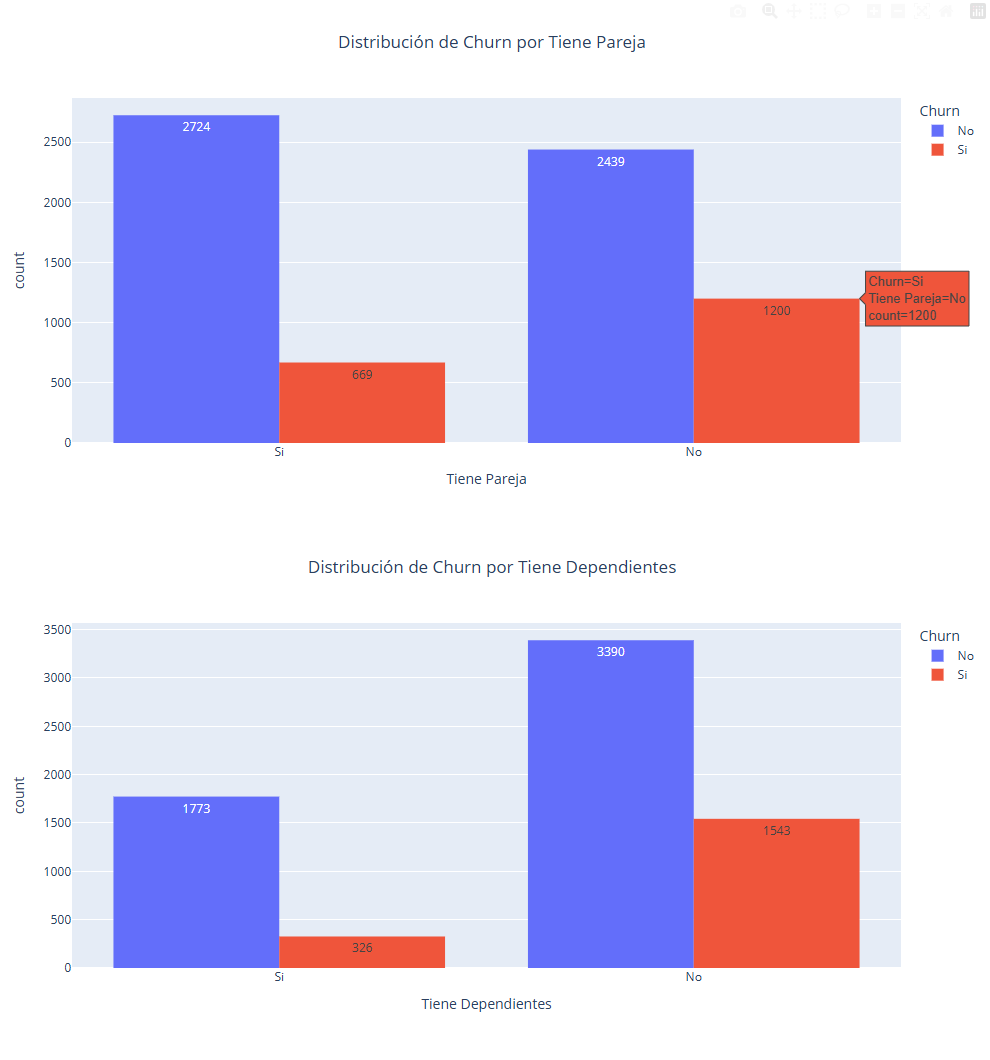

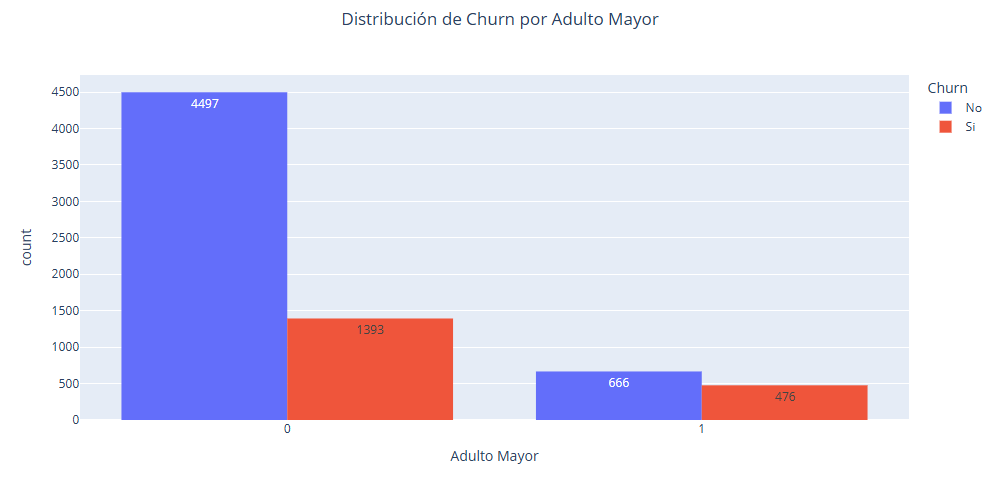

* **El Problema de la Fibra Óptica (Servicio de Internet):** Se descubrió una vulnerabilidad operativa grave. Los clientes que contratan **Fibra Óptica** tienen una tasa de abandono desproporcionadamente mayor frente a los que usan DSL. Al observar la permanencia, existe un pico masivo de cancelaciones de Fibra Óptica **en el primer mes de servicio**, lo que sugiere problemas de instalación, expectativas no cumplidas o fallas técnicas iniciales.

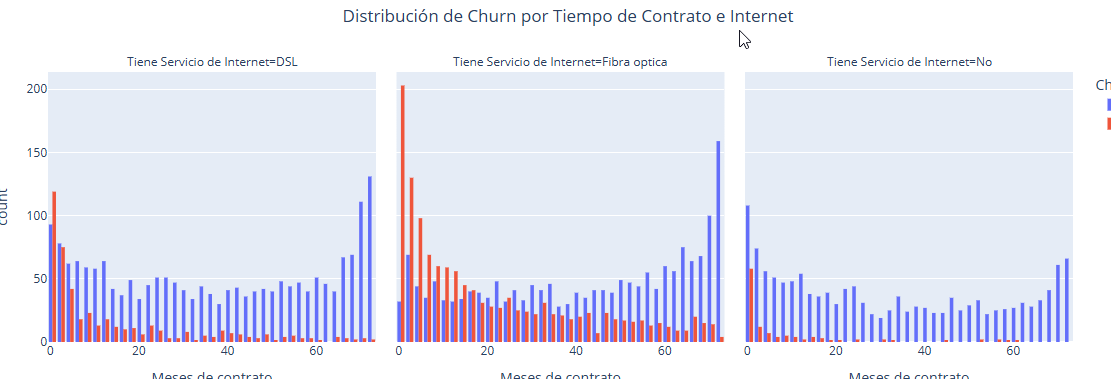


* **Impacto del Tipo de Contrato y Permanencia:** Existe un riesgo crítico en los contratos de tipo "Mes a mes" (Month-to-month), acumulando la gran mayoría de las cancelaciones de la compañía. A medida que el cliente logra superar la barrera del primer año, la probabilidad de fuga disminuye drásticamente, haciendo que los contratos anuales o bianuales sean casi infalibles para la retención.


* **Factor Financiero (Cargos Mensuales):** El análisis de distribución (Boxplots) revela que los clientes que abandonan la empresa pagan, en promedio, facturas notablemente más altas (con una mediana cercana a los $80) en comparación con los clientes que se quedan (mediana de ~$60).

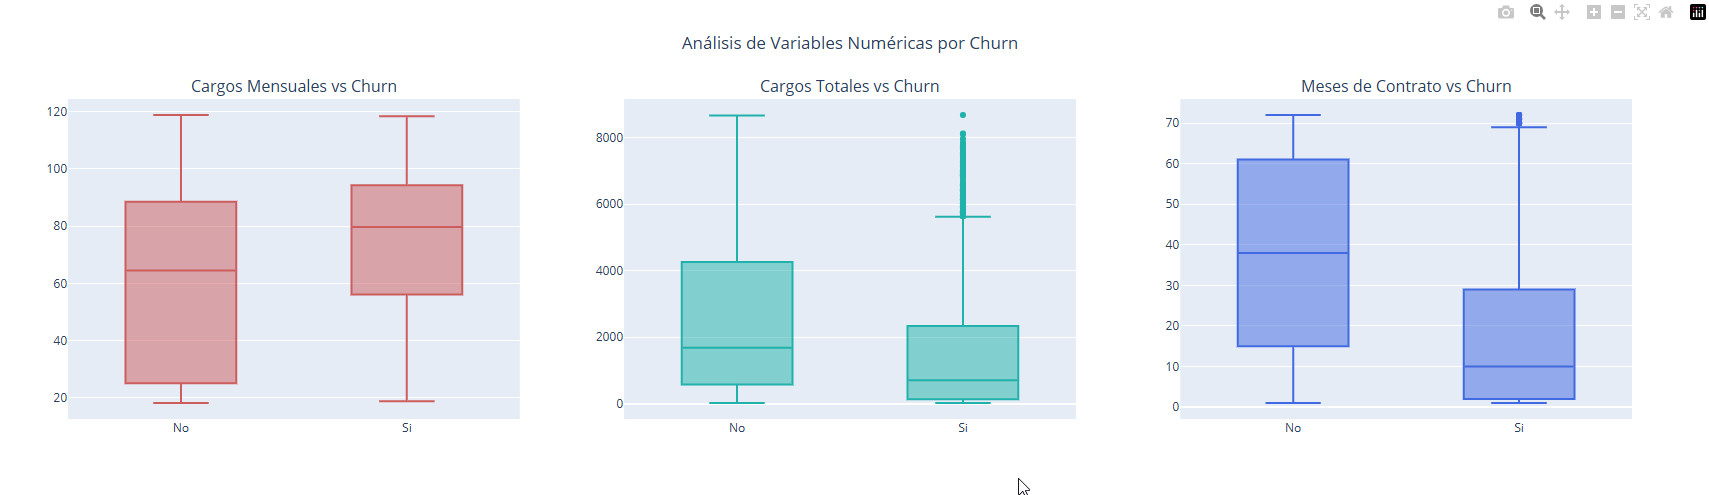


* **Método de Pago y Facturación Electrónica:** Curiosamente, el uso de "Facturación Electrónica" (Paperless Billing) está altamente correlacionado con el abandono. Adicionalmente, los usuarios que pagan de forma manual mediante "Cheque Electrónico" son considerablemente más propensos a cancelar el servicio en los primeros meses frente a aquellos con métodos de pago automáticos (tarjetas de crédito o transferencias).

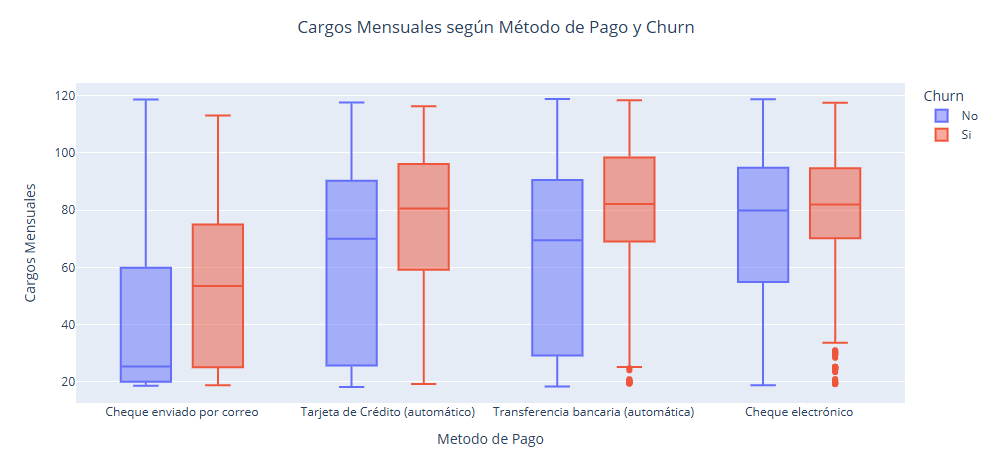


* **Escudo de Retención (Servicios Adicionales):** La ausencia de servicios de valor agregado actúa como un catalizador para el Churn. Los gráficos demuestran que los clientes que **no** cuentan con "Seguridad en Línea", "Respaldo en Línea", "Protección de Dispositivo" o "Soporte Técnico" abandonan la compañía a un ritmo alarmante frente a quienes sí los tienen.



## 4. Conclusiones y Posibles Planes de Acción

Con base en los datos analizados, el problema principal de fuga se concentra en los **clientes nuevos (sin dependientes), con altos cargos mensuales, servicio de Fibra Óptica y contratos mes a mes**. Se sugiere a la compañía evaluar las siguientes acciones estratégicas:

1. **Auditoría urgente al servicio de Fibra Óptica:** Investigar qué está ocurriendo durante los primeros 30 días de instalación de este servicio (calidad, intermitencia, servicio al cliente), ya que es el principal sumidero de clientes.
2. **Estrategia de Empaquetamiento (Bundling):** Ofrecer la inclusión gratuita o con gran descuento de servicios como "Seguridad en Línea" o "Soporte Técnico" a los clientes de Fibra Óptica, ya que los datos prueban que tener estos servicios "amarra" al cliente y reduce drásticamente el Churn.
3. **Incentivos de Migración de Contrato:** Diseñar campañas para que los clientes "mes a mes" que pagan mediante cheque electrónico migren a contratos anuales con pagos automáticos, ofreciendo descuentos que reduzcan sus cargos mensuales (acercándolos a la mediana de retención de $60).
